# EDA: `order_items`

Разведочный анализ таблицы `order_items` из базы данных Olist.


### Импорты

In [1]:
import pandas as pd

import matplotlib.pyplot as plt

from sqlalchemy import create_engine
from sqlalchemy.engine import URL

In [2]:
import os
from dotenv import load_dotenv
load_dotenv()

True

### Конфигурация

In [3]:
USERNAME = os.getenv("DB_USERNAME")
PASSWORD = os.getenv("DB_PASSWORD")
HOST = os.getenv("DB_HOST")
PORT = os.getenv("DB_PORT")
DATABASE = os.getenv("DB_NAME")

url = URL.create(
    drivername="postgresql+psycopg2",
    username=USERNAME,
    password=PASSWORD,
    host=HOST,
    port=PORT,
    database=DATABASE,
)

In [4]:
connection = create_engine(url=url)

## Анализ данных


In [5]:
read_sql_query = "SELECT * FROM order_items"
df = pd.read_sql(sql=read_sql_query, con=connection)

In [6]:
df.head()

,order_item_id,order_id,shipping_limit_date,price,freight_value,product_id,seller_id
0,1,00010242fe8c5a6d1ba2dd792cb16214,2017-09-19 09:45:35,58.90,13.29,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202
1,1,00018f77f2f0320c557190d7a144bdd3,2017-05-03 11:05:13,239.90,19.93,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36
2,1,000229ec398224ef6ca0657da4fc703e,2018-01-18 14:48:30,199.00,17.87,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d
3,1,00024acbcdf0a6daa1e931b038114c75,2018-08-15 10:10:18,12.99,12.79,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4
4,1,00042b26cf59d7ce69dfabb4e55b4fd9,2017-02-13 13:57:51,199.90,18.14,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   order_item_id        112650 non-null  int64         
 1   order_id             112650 non-null  str           
 2   shipping_limit_date  112650 non-null  datetime64[us]
 3   price                112650 non-null  float64       
 4   freight_value        112650 non-null  float64       
 5   product_id           112650 non-null  str           
 6   seller_id            112650 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), str(3)
memory usage: 6.0 MB


In [8]:
df.describe(include='all')

,order_item_id,order_id,shipping_limit_date,price,freight_value,product_id,seller_id
count,112650.000000,112650,112650,112650.000000,112650.000000,112650,112650
unique,NaN,98666,NaN,NaN,NaN,32951,3095
top,NaN,8272b63d03f5f79c56e9e4120aec44ef,NaN,NaN,NaN,aca2eb7d00ea1a7b8ebd4e68314663af,6560211a19b47992c3666cc44a7e94c0
freq,NaN,21,NaN,NaN,NaN,527,2033
mean,1.197834,NaN,2018-01-07 15:36:52.192685,120.653739,19.990320,NaN,NaN
min,1.000000,NaN,2016-09-19 00:15:34,0.850000,0.000000,NaN,NaN
25%,1.000000,NaN,2017-09-20 20:57:27.500000,39.900000,13.080000,NaN,NaN
50%,1.000000,NaN,2018-01-26 13:59:35,74.990000,16.260000,NaN,NaN
75%,1.000000,NaN,2018-05-10 14:34:00.750000,134.900000,21.150000,NaN,NaN
max,21.000000,NaN,2020-04-09 22:35:08,6735.000000,409.680000,NaN,NaN


In [9]:
df.memory_usage(deep=True)

Index                      132
order_item_id           901200
order_id               9124650
shipping_limit_date     901200
price                   901200
freight_value           901200
product_id             9124650
seller_id              9124650
dtype: int64

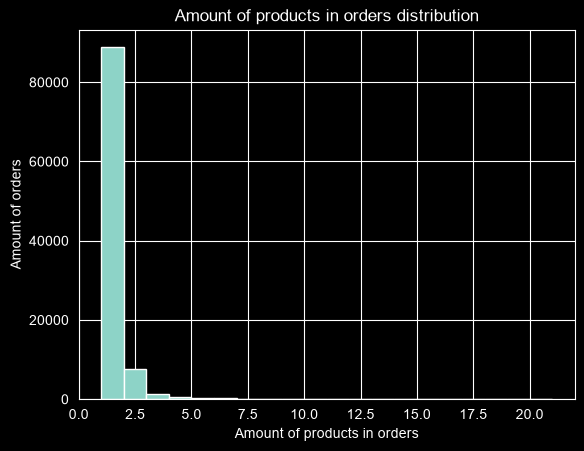

In [10]:
items_per_order = (
    df.groupby("order_id")["order_item_id"]
    .max()
)
plt.hist(items_per_order, bins=20)

plt.xlabel("Amount of products in orders")
plt.ylabel("Amount of orders")
plt.title("Amount of products in orders distribution")

plt.show()